Tasks

In [ ]:
#Bank Account 
class BankAccount:
    def __init__(self, balance=0):
        self.balance = balance
    def deposit(self, amount):
        self.balance += amount
        return self.balance
    def withdraw(self, amount):
        if amount > self.balance:
            raise ValueError("Insufficient funds")
        self.balance -= amount
        return self.balance
    def get_balance(self):
        return self.balance
acc = BankAccount(100)
acc.deposit(50)
acc.withdraw(30)
print(acc.get_balance())  


120


In [ ]:
#Numpy Array
import numpy as np
arr = np.arange(1, 13)  
print("Original:", arr)
print("Slice [2:7]:", arr[2:7])
print("Every 2nd element:", arr[::2])
arr2d = arr.reshape(3, 4)
print("Reshaped (3x4):\n", arr2d)
print("Row 1:", arr2d[1])
print("Column 2:", arr2d[:, 2])
print("Sub-matrix:\n", arr2d[0:2, 1:3])
print("Mean:", arr.mean())
print("Std Dev:", arr.std())
print("Max:", arr.max())
print("Min:", arr.min())
print("Column-wise mean:", arr2d.mean(axis=0))
print("Row-wise max:", arr2d.max(axis=1))

Original: [ 1  2  3  4  5  6  7  8  9 10 11 12]
Slice [2:7]: [3 4 5 6 7]
Every 2nd element: [ 1  3  5  7  9 11]
Reshaped (3x4):
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
Row 1: [5 6 7 8]
Column 2: [ 3  7 11]
Sub-matrix:
 [[2 3]
 [6 7]]
Mean: 6.5
Std Dev: 3.452052529534663
Max: 12
Min: 1
Column-wise mean: [5. 6. 7. 8.]
Row-wise max: [ 4  8 12]


In [ ]:
#CSV File 
import pandas as pd
import numpy as np
df = pd.read_csv('data.csv')   
print("=== INFO ===")
print(df.info())
print("\n=== DESCRIBE ===")
print(df.describe(include='all'))   
print("\n=== HEAD ===")
print(df.head())
print("\n=== MISSING VALUES (count) ===")
print(df.isnull().sum())
print("\n=== MISSING VALUES (%) ===")
print((df.isnull().mean() * 100).round(2))
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])
df.fillna(0, inplace=True)
print("\n=== VERIFICATION ===")
print("Total missing values remaining:", df.isnull().sum().sum())
print(df.info())

=== INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se            

C:\Users\admin\AppData\Local\Temp\ipykernel_14112\577131542.py:40: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


C:\Users\admin\AppData\Local\Temp\ipykernel_14112\3426634739.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


Filtered on 'id' > mean: (81, 33)

=== Grouped Means ===
diagnosis
M    3.681805e+07
B    2.654382e+07
Name: id, dtype: float64


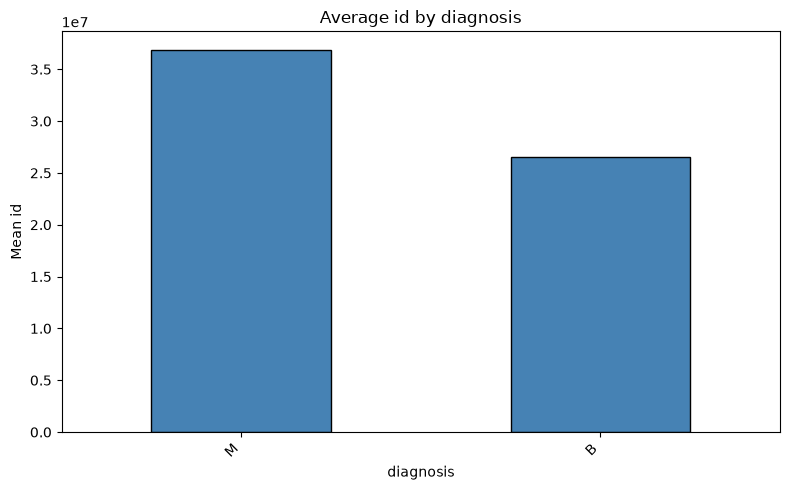

In [ ]:
#Mini EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('data.csv')   
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns
if len(num_cols) > 0:
    col_to_filter = num_cols[0]
    filtered_df = df[df[col_to_filter] > df[col_to_filter].mean()]
    print(f"Filtered on '{col_to_filter}' > mean:", filtered_df.shape)
else:
    filtered_df = df.copy()
if len(cat_cols) > 0 and len(num_cols) > 0:
    group_col = cat_cols[0]
    value_col = num_cols[0]
    grouped = df.groupby(group_col)[value_col].mean().sort_values(ascending=False)
    print("\n=== Grouped Means ===")
    print(grouped)
else:
    grouped = None
    print("Not enough categorical/numeric columns to group by.")
if grouped is not None:
    plt.figure(figsize=(8, 5))
    grouped.plot(kind='bar', color='steelblue', edgecolor='black')
    plt.title(f"Average {value_col} by {group_col}")
    plt.xlabel(group_col)
    plt.ylabel(f"Mean {value_col}")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Practice Sheet 

In [ ]:
#OOP
class Book:
    def __init__(self, title, author, isbn, copies=1):
        self.title = title
        self.author = author
        self.isbn = isbn
        self.total_copies = copies
        self.available_copies = copies
    def is_available(self):
        return self.available_copies > 0
    def __str__(self):
        return f"'{self.title}' by {self.author} ({self.available_copies}/{self.total_copies} available)"
class Member:
    def __init__(self, name, member_id):
        self.name = name
        self.member_id = member_id
        self.borrowed_books = []
    def borrow_book(self, book):
        if not book.is_available():
            print(f"'{book.title}' is currently unavailable.")
            return False
        book.available_copies -= 1
        self.borrowed_books.append(book)
        print(f"{self.name} borrowed '{book.title}'.")
        return True
    def return_book(self, book):
        if book in self.borrowed_books:
            book.available_copies += 1
            self.borrowed_books.remove(book)
            print(f"{self.name} returned '{book.title}'.")
            return True
        print(f"{self.name} doesn't have '{book.title}' borrowed.")
        return False
    def __str__(self):
        titles = [b.title for b in self.borrowed_books]
        return f"{self.name} (ID: {self.member_id}) - Borrowed: {titles or 'None'}"
class Library:
    def __init__(self, name):
        self.name = name
        self.books = []
        self.members = []
    def add_book(self, book):
        self.books.append(book)
    def register_member(self, member):
        self.members.append(member)
    def find_book(self, title):
        for book in self.books:
            if book.title.lower() == title.lower():
                return book
        return None
    def show_catalog(self):
        print(f"\n--- {self.name} Catalog ---")
        for book in self.books:
            print(book)
library = Library("City Library")
b1 = Book("1984", "George Orwell", "111", copies=2)
b2 = Book("Dune", "Frank Herbert", "222", copies=1)
library.add_book(b1)
library.add_book(b2)
alice = Member("Alice", "M001")
bob = Member("Bob", "M002")
library.register_member(alice)
library.register_member(bob)
library.show_catalog()
alice.borrow_book(b1)
bob.borrow_book(b1)
bob.borrow_book(b2)
bob.borrow_book(b2)   
library.show_catalog()
print(alice)
print(bob)
alice.return_book(b1)
library.show_catalog()


--- City Library Catalog ---
'1984' by George Orwell (2/2 available)
'Dune' by Frank Herbert (1/1 available)
Alice borrowed '1984'.
Bob borrowed '1984'.
Bob borrowed 'Dune'.
'Dune' is currently unavailable.

--- City Library Catalog ---
'1984' by George Orwell (0/2 available)
'Dune' by Frank Herbert (0/1 available)
Alice (ID: M001) - Borrowed: ['1984']
Bob (ID: M002) - Borrowed: ['1984', 'Dune']
Alice returned '1984'.

--- City Library Catalog ---
'1984' by George Orwell (1/2 available)
'Dune' by Frank Herbert (0/1 available)


In [ ]:
#Numpy
import numpy as np
A = np.array([[1, 2, 3],
              [4, 5, 6]])          
B = np.array([[7, 8],
              [9, 10],
              [11, 12]])           
C = A @ B
print("Using @ operator:\n", C)
C2 = np.dot(A, B)
print("\nUsing np.dot():\n", C2)
C3 = np.matmul(A, B)
print("\nUsing np.matmul():\n", C3)
print("\nAll equal:", np.array_equal(C, C2) and np.array_equal(C2, C3))

Using @ operator:
 [[ 58  64]
 [139 154]]

Using np.dot():
 [[ 58  64]
 [139 154]]

Using np.matmul():
 [[ 58  64]
 [139 154]]

All equal: True


(891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

=== INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived  

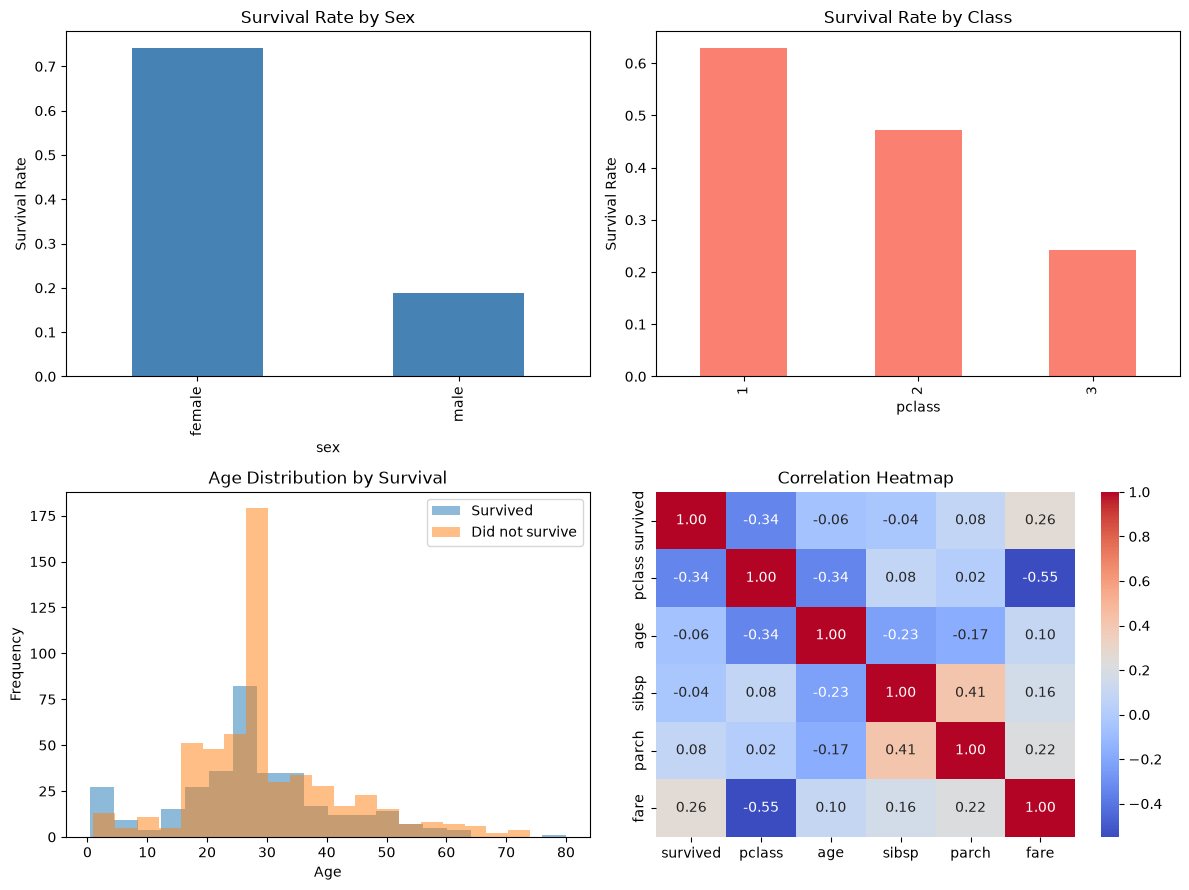

In [ ]:
#Pandas
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df = sns.load_dataset('titanic')   
print(df.shape)
print(df.head())

# ------------------------------
# 2. Basic exploration
# ------------------------------
print("\n=== INFO ===")
print(df.info())

print("\n=== DESCRIBE ===")
print(df.describe(include='all'))

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

# ------------------------------
# 3. Clean missing values
# ------------------------------
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df.drop(columns=['deck'], inplace=True, errors='ignore')  # too many missing

print("\nMissing after cleanup:", df.isnull().sum().sum())

# ------------------------------
# 4. Filter
# ------------------------------
survivors = df[df['survived'] == 1]
print(f"\nSurvivors: {len(survivors)} / {len(df)} ({len(survivors)/len(df)*100:.1f}%)")

# ------------------------------
# 5. Group by analysis
# ------------------------------
print("\n=== Survival rate by sex ===")
print(df.groupby('sex')['survived'].mean())

print("\n=== Survival rate by class ===")
print(df.groupby('pclass')['survived'].mean())

print("\n=== Survival rate by sex & class ===")
print(df.groupby(['pclass', 'sex'])['survived'].mean())

print("\n=== Average age & fare by survival ===")
print(df.groupby('survived')[['age', 'fare']].mean())

# ------------------------------
# 6. Correlation
# ------------------------------
num_df = df.select_dtypes(include=np.number)
print("\n=== Correlation with survival ===")
print(num_df.corr()['survived'].sort_values(ascending=False))

# ------------------------------
# 7. Visualizations
# ------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Survival by sex
df.groupby('sex')['survived'].mean().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Survival Rate by Sex')
axes[0,0].set_ylabel('Survival Rate')

# Survival by class
df.groupby('pclass')['survived'].mean().plot(kind='bar', ax=axes[0,1], color='salmon')
axes[0,1].set_title('Survival Rate by Class')
axes[0,1].set_ylabel('Survival Rate')

# Age distribution by survival
df[df['survived']==1]['age'].plot(kind='hist', alpha=0.5, label='Survived', ax=axes[1,0], bins=20)
df[df['survived']==0]['age'].plot(kind='hist', alpha=0.5, label='Did not survive', ax=axes[1,0], bins=20)
axes[1,0].set_title('Age Distribution by Survival')
axes[1,0].set_xlabel('Age')
axes[1,0].legend()

# Correlation heatmap
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1,1])
axes[1,1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()